#### 0: Importing the Data

In [1]:
import pandas as pd

df = pd.read_parquet("hf://datasets/Shekswess/social-media-instruction/data/train-00000-of-00001.parquet")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


#### 1: EDA Step

In [2]:
df.head()

,keyword,topic,language,generated_text
0,Facebook algorithm,Social Media,English,{'messages': [{'content': 'You are a social me...
1,hashtag trends,Social Media,English,{'messages': [{'content': 'You are a social me...
2,tweet analytics,Social Media,English,{'messages': [{'content': 'You are a social me...
3,Instagram reach,Social Media,English,{'messages': [{'content': 'You are a social me...
4,Facebook success,Social Media,English,{'messages': [{'content': 'You are a social me...


In [3]:
df.tail()

,keyword,topic,language,generated_text
495,content measurement,Social Media,English,{'messages': [{'content': 'You are a social me...
496,post insights,Social Media,English,{'messages': [{'content': 'You are a social me...
497,Instagram planning,Social Media,English,{'messages': [{'content': 'You are a social me...
498,Instagram strategy,Social Media,English,{'messages': [{'content': 'You are a social me...
499,content planning,Social Media,English,{'messages': [{'content': 'You are a social me...


In [4]:
df.columns

Index(['keyword', 'topic', 'language', 'generated_text'], dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   keyword         500 non-null    object
 1   topic           500 non-null    object
 2   language        500 non-null    object
 3   generated_text  500 non-null    object
dtypes: object(4)
memory usage: 15.8+ KB


In [6]:
df.isnull().sum()

,0
keyword,0
topic,0
language,0
generated_text,0


#### 2. Data Cleaning

In [7]:
# Basic cleaning - handle dictionary columns
df_clean = df.copy()

# Convert dictionary columns to strings for duplicate checking
df_clean['generated_text_str'] = df_clean['generated_text'].astype(str)

# Now drop duplicates
df_clean = df_clean.drop_duplicates(subset=['generated_text_str'])

# Drop the temporary string column
df_clean = df_clean.drop(columns=['generated_text_str'])

# Drop NA values
df_clean = df_clean.dropna()

#### 3. Extracting Linguistic Features

In [8]:
# Sentiment analysis
from textblob import TextBlob

def get_sentiment(text):
    if isinstance(text, dict):  # Handle JSON/dict format
        messages = text.get('messages', [])
        content = ' '.join([msg.get('content', '') for msg in messages])
    else:
        content = str(text)
    return TextBlob(content).sentiment.polarity

df['sentiment'] = df['generated_text'].apply(get_sentiment)

#### 4. Word Usage Patterns

In [9]:
from collections import Counter
import re

def get_word_patterns(text):
    if isinstance(text, dict):
        messages = text.get('messages', [])
        content = ' '.join([msg.get('content', '') for msg in messages])
    else:
        content = str(text)
    words = re.findall(r'\w+', content.lower())
    return Counter(words)

df['word_counts'] = df['generated_text'].apply(get_word_patterns)

#### 5. Engagement Metrics (example)

In [10]:
# Simple engagement metric based on text length
def engagement_metric(text):
    if isinstance(text, dict):
        messages = text.get('messages', [])
        content = ' '.join([msg.get('content', '') for msg in messages])
    else:
        content = str(text)
    return len(content.split())  # Word count as proxy

df['engagement'] = df['generated_text'].apply(engagement_metric)

#### 6. Quick Analysis

In [11]:
# Summary stats
print(f"Average Sentiment: {df['sentiment'].mean():.2f}")
print(f"Average Engagement: {df['engagement'].mean():.2f} words")

# Most common words
all_words = sum(df['word_counts'], Counter())
print("Top 5 words:", all_words.most_common(5))

Average Sentiment: 0.20
Average Engagement: 229.33 words
Top 5 words: [('and', 3228), ('to', 2814), ('content', 2726), ('your', 2292), ('a', 1766)]


#### PLotting the Graph for Sentiement and Enagmemnt

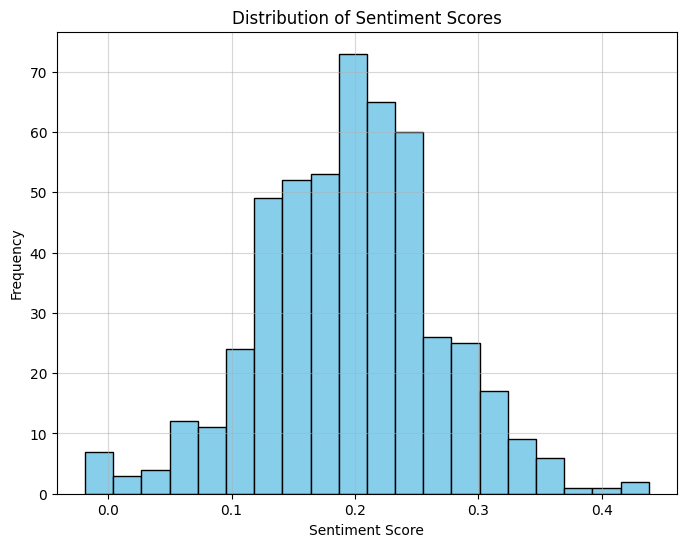

In [12]:
#  plot the sentiment

import matplotlib.pyplot as plt

# Plot sentiment distribution
plt.figure(figsize=(8, 6))
plt.hist(df['sentiment'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Sentiment Scores')
plt.xlabel('Sentiment Score')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.5)
plt.show()


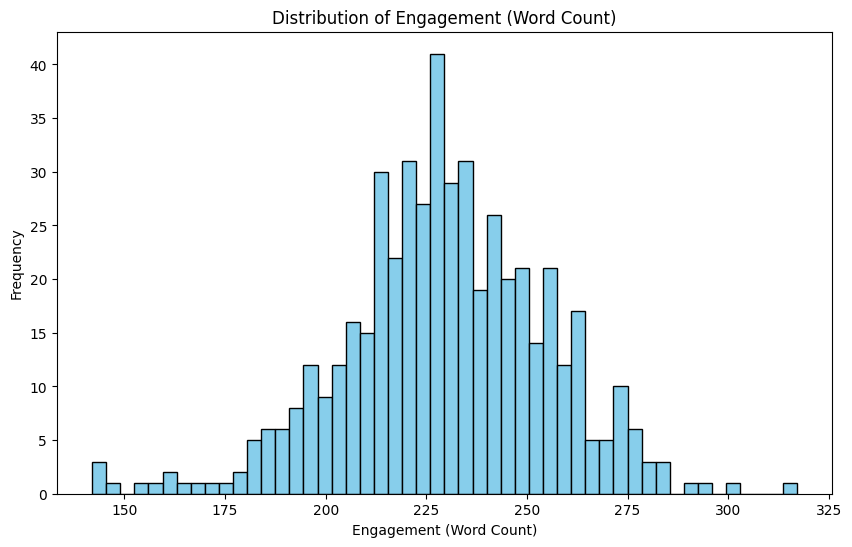

In [13]:
# plot the engagement

import matplotlib.pyplot as plt

# Plot engagement distribution
plt.figure(figsize=(10, 6))
plt.hist(df['engagement'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Engagement (Word Count)')
plt.xlabel('Engagement (Word Count)')
plt.ylabel('Frequency')
plt.show()


In [14]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
import torch
from torch.utils.data import Dataset
import matplotlib.pyplot as plt
import os
import re

In [15]:
# Disable wandb
os.environ["WANDB_DISABLED"] = "true"

# Assuming df is already loaded and cleaned as in your previous code
# Extract text from the nested JSON structure
def extract_text(text_obj):
    if isinstance(text_obj, dict):
        messages = text_obj.get('messages', [])
        content = ' '.join([msg.get('content', '') for msg in messages])
    else:
        content = str(text_obj)
    return content

# Apply the function to extract text
df['text_content'] = df['generated_text'].apply(extract_text)

# For demonstration, let's create a binary classification task
# We'll predict if a post has high engagement (above median) or low engagement
median_engagement = df['engagement'].median()
df['high_engagement'] = (df['engagement'] > median_engagement).astype(int)

# Split the data into train, validation and test sets
X = df['text_content']
y = df['high_engagement']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Training set size: {len(X_train)}")
print(f"Validation set size: {len(X_val)}")
print(f"Test set size: {len(X_test)}")

Training set size: 350
Validation set size: 75
Test set size: 75


In [16]:
# 1. Traditional classifiers (TF-IDF + RandomForest and LogisticRegression)
# Define pipelines
rf_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('clf', RandomForestClassifier(random_state=42))
])

lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('clf', LogisticRegression(random_state=42, max_iter=1000))
])

# Hyperparameter tuning for RandomForest
rf_param_grid = {
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [None, 10, 20]
}

rf_grid = GridSearchCV(rf_pipeline, rf_param_grid, cv=3, scoring='f1')
rf_grid.fit(X_train, y_train)

print(f"Best parameters for RandomForest: {rf_grid.best_params_}")
print(f"Best cross-validation score for RandomForest: {rf_grid.best_score_:.4f}")

# Hyperparameter tuning for LogisticRegression
lr_param_grid = {
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'clf__C': [0.1, 1.0, 10.0]
}

lr_grid = GridSearchCV(lr_pipeline, lr_param_grid, cv=3, scoring='f1')
lr_grid.fit(X_train, y_train)

print(f"Best parameters for LogisticRegression: {lr_grid.best_params_}")
print(f"Best cross-validation score for LogisticRegression: {lr_grid.best_score_:.4f}")

# Evaluate the models on the test set
rf_pred = rf_grid.predict(X_test)
lr_pred = lr_grid.predict(X_test)

# Create a dictionary to store all metrics
all_metrics = {
    "Random Forest": {},
    "Logistic Regression": {},
    "BERT": {}
}

Best parameters for RandomForest: {'clf__max_depth': 10, 'clf__n_estimators': 200, 'tfidf__ngram_range': (1, 1)}
Best cross-validation score for RandomForest: 0.7796
Best parameters for LogisticRegression: {'clf__C': 10.0, 'tfidf__ngram_range': (1, 2)}
Best cross-validation score for LogisticRegression: 0.7451


In [17]:

# Calculate metrics for traditional models
for model_name, preds in [("Random Forest", rf_pred), ("Logistic Regression", lr_pred)]:
    all_metrics[model_name]["accuracy"] = accuracy_score(y_test, preds)
    all_metrics[model_name]["precision"] = precision_score(y_test, preds)
    all_metrics[model_name]["recall"] = recall_score(y_test, preds)
    all_metrics[model_name]["f1"] = f1_score(y_test, preds)

    print(f"\n{model_name} Performance Metrics:")
    print(f"Accuracy: {all_metrics[model_name]['accuracy']:.4f}")
    print(f"Precision: {all_metrics[model_name]['precision']:.4f}")
    print(f"Recall: {all_metrics[model_name]['recall']:.4f}")
    print(f"F1-Score: {all_metrics[model_name]['f1']:.4f}")
    print("\nDetailed Classification Report:")
    print(classification_report(y_test, preds))


Random Forest Performance Metrics:
Accuracy: 0.7467
Precision: 0.7059
Recall: 0.7273
F1-Score: 0.7164

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.76      0.77        42
           1       0.71      0.73      0.72        33

    accuracy                           0.75        75
   macro avg       0.74      0.74      0.74        75
weighted avg       0.75      0.75      0.75        75


Logistic Regression Performance Metrics:
Accuracy: 0.7467
Precision: 0.7059
Recall: 0.7273
F1-Score: 0.7164

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.76      0.77        42
           1       0.71      0.73      0.72        33

    accuracy                           0.75        75
   macro avg       0.74      0.74      0.74        75
weighted avg       0.75      0.75      0.75        75



In [18]:
# 2. BERT Model for sequence classification
# Create a custom dataset class for BERT
class SocialMediaDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts.iloc[idx])
        label = self.labels.iloc[idx]

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Initialize BERT tokenizer and model
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

# Create datasets
train_dataset = SocialMediaDataset(X_train, y_train, tokenizer)
val_dataset = SocialMediaDataset(X_val, y_val, tokenizer)
test_dataset = SocialMediaDataset(X_test, y_test, tokenizer)

# Define training arguments - Fixed to remove unsupported parameters
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
    eval_steps=500,
    save_steps=500,
    report_to="none"  # Disable wandb reporting
)

# Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

# Train the model
trainer.train()

# Evaluate BERT model on test set
bert_results = trainer.evaluate(test_dataset)
print(f"\nBERT Model Performance:")
print(f"Loss: {bert_results['eval_loss']:.4f}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss
10,0.840700
20,0.712700
30,0.699500
40,0.697200
50,0.641700
60,0.634700



BERT Model Performance:
Loss: 0.5323


Accuracy: 0.7600
Precision: 0.7027
Recall: 0.7879
F1-Score: 0.7429

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.74      0.78        42
           1       0.70      0.79      0.74        33

    accuracy                           0.76        75
   macro avg       0.76      0.76      0.76        75
weighted avg       0.77      0.76      0.76        75


--- Model Comparison ---
                     accuracy  precision    recall        f1
Random Forest        0.746667   0.705882  0.727273  0.716418
Logistic Regression  0.746667   0.705882  0.727273  0.716418
BERT                 0.760000   0.702703  0.787879  0.742857


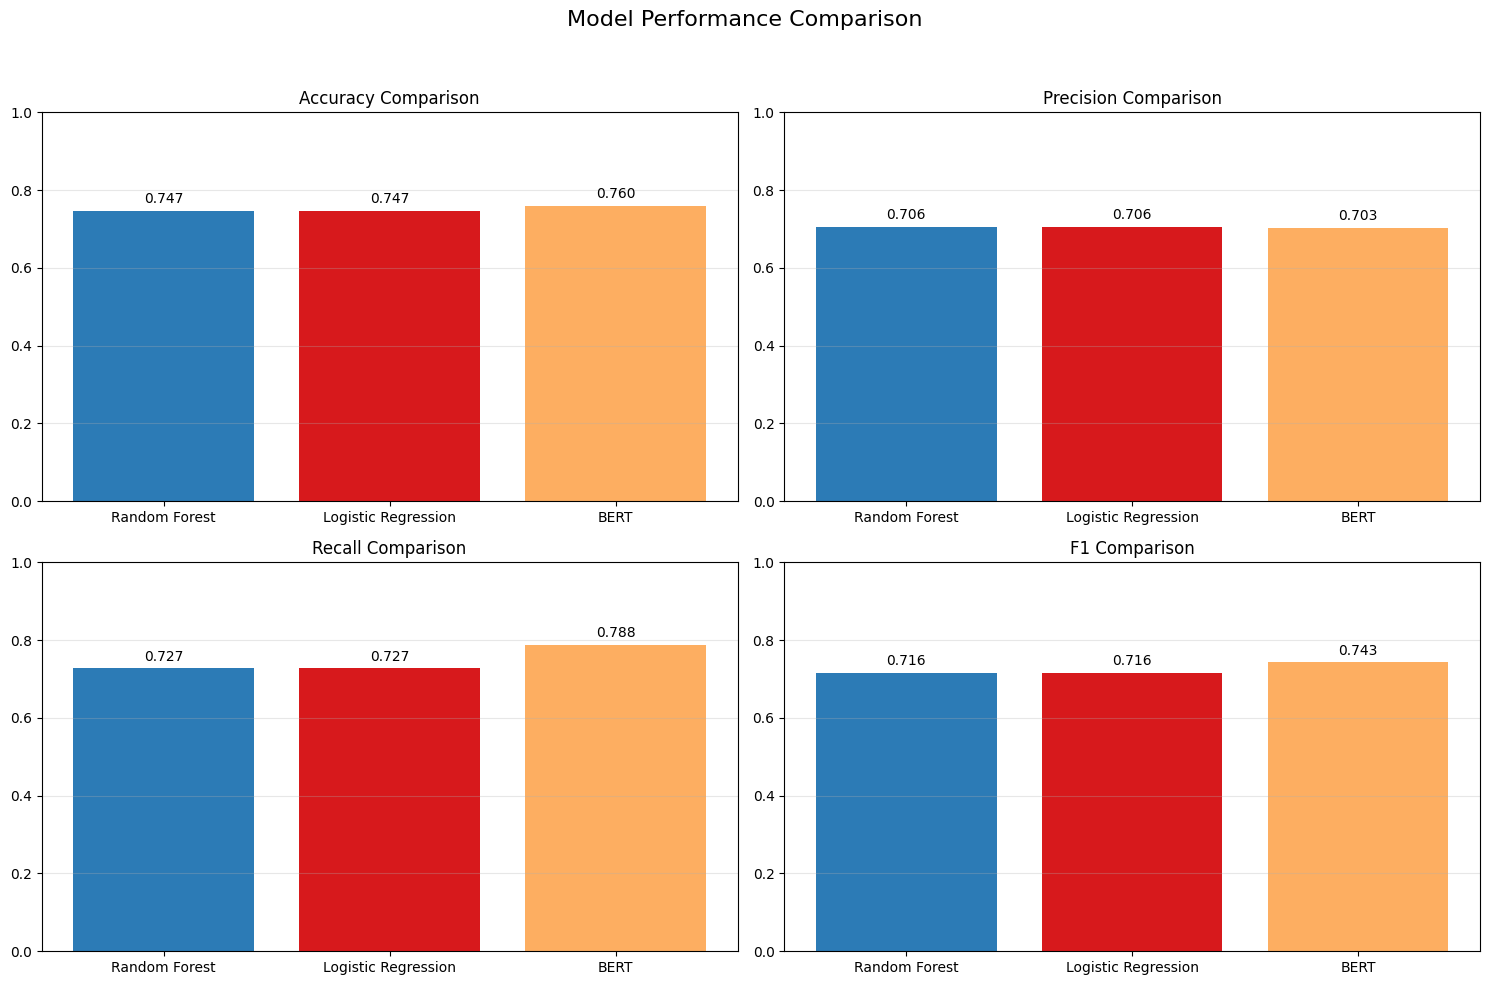

<Figure size 1200x600 with 0 Axes>

In [19]:


# Get predictions from BERT
def get_predictions(trainer, dataset):
    predictions = trainer.predict(dataset)
    preds = np.argmax(predictions.predictions, axis=1)
    return preds

bert_preds = get_predictions(trainer, test_dataset)

# Calculate metrics for BERT
all_metrics["BERT"]["accuracy"] = accuracy_score(y_test, bert_preds)
all_metrics["BERT"]["precision"] = precision_score(y_test, bert_preds)
all_metrics["BERT"]["recall"] = recall_score(y_test, bert_preds)
all_metrics["BERT"]["f1"] = f1_score(y_test, bert_preds)

print(f"Accuracy: {all_metrics['BERT']['accuracy']:.4f}")
print(f"Precision: {all_metrics['BERT']['precision']:.4f}")
print(f"Recall: {all_metrics['BERT']['recall']:.4f}")
print(f"F1-Score: {all_metrics['BERT']['f1']:.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, bert_preds))

# Create a DataFrame for easy comparison
comparison_df = pd.DataFrame(all_metrics).T
print("\n--- Model Comparison ---")
print(comparison_df)

# Save metrics to CSV for future reference
comparison_df.to_csv("model_comparison.csv")

# Create simpler and more attractive visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Model Performance Comparison', fontsize=16)

metrics = ['accuracy', 'precision', 'recall', 'f1']
models = list(all_metrics.keys())
colors = ['#2C7BB6', '#D7191C', '#FDAE61']

for i, (metric, ax) in enumerate(zip(metrics, axes.flatten())):
    values = [all_metrics[model][metric] for model in models]
    ax.bar(models, values, color=colors)
    ax.set_title(f'{metric.capitalize()} Comparison')
    ax.set_ylim(0, 1)
    ax.grid(axis='y', alpha=0.3)

    # Add value labels on top of bars
    for j, value in enumerate(values):
        ax.text(j, value + 0.02, f'{value:.3f}', ha='center')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Create a single consolidated bar chart
plt.figure(figsize=(12, 6))
x = np.arange(len(models))
width = 0.2



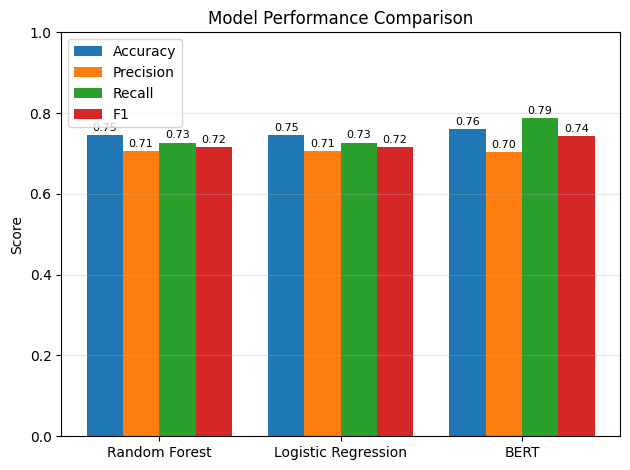

In [20]:
for i, metric in enumerate(metrics):
    values = [all_metrics[model][metric] for model in models]
    plt.bar(x + (i - 1.5) * width, values, width, label=metric.capitalize())

    # Add value labels
    for j, value in enumerate(values):
        plt.text(j + (i - 1.5) * width, value + 0.01, f'{value:.2f}', ha='center', fontsize=8)

plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.xticks(x, models)
plt.ylim(0, 1)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison_combined.png', dpi=300, bbox_inches='tight')
plt.show()

In [72]:
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [73]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Initialize VADER
sia = SentimentIntensityAnalyzer()

# Hybrid prediction: Low, Mixed, High
def predict_with_sentiment_v2(text, tokenizer, model, confidence_threshold=0.7):
    pred_class, prob = predict_with_bert(text, tokenizer, model)
    sentiment_score = sia.polarity_scores(text)['compound']

    # Get confidence of BERT prediction
    bert_confidence = max(prob)

    # Sentiment-based label
    if sentiment_score >= 0.55:
        sentiment_label = "High"
    elif sentiment_score <= -0.3:
        sentiment_label = "Low"
    else:
        sentiment_label = "Mixed"


    # Final prediction logic
    if bert_confidence >= confidence_threshold:
        # If BERT is confident, trust it
        final_label = "High" if pred_class == 1 else "Low"
    else:
        # If BERT is unsure, defer to sentiment
        final_label = sentiment_label

    return final_label, prob, sentiment_score, bert_confidence, sentiment_label

# Evaluation function with Mixed class
def evaluate_with_sentiment_v2(test_data, tokenizer, model):
    results = []
    for text, expected_class in test_data:
        pred_label, prob, sentiment_score, confidence, sentiment_label = predict_with_sentiment_v2(text, tokenizer, model)
        results.append((text, expected_class, pred_label, prob, sentiment_score, confidence, sentiment_label))
    return results

# Run evaluation
results = evaluate_with_sentiment_v2(test_data, tokenizer, model)

# Print results
for res in results:
    text, expected, predicted, probs, sent, conf, sent_lbl = res
    print(f"Text: {text}")
    print(f"Expected: {expected} | Predicted: {predicted} | BERT Confidence: {conf:.2f}")
    print(f"Probabilities: {probs} | Sentiment: {sent:.4f} ({sent_lbl})\n")


Text: I had a really great day today. Lots of people engaged with my post!
Expected: High | Predicted: High | BERT Confidence: 0.24
Probabilities: [0.1687658131122589, 0.21423614025115967, 0.17136667668819427, 0.2383766621351242, 0.20725473761558533] | Sentiment: 0.8118 (High)

Text: No one liked or commented on my post. It’s so sad.
Expected: Low | Predicted: Low | BERT Confidence: 0.25
Probabilities: [0.13636791706085205, 0.2139665186405182, 0.16283497214317322, 0.24839399755001068, 0.23843665421009064] | Sentiment: -0.5254 (Low)

Text: The feedback was mixed. Some loved it, some didn’t really care.
Expected: Low | Predicted: High | BERT Confidence: 0.25
Probabilities: [0.17538686096668243, 0.19694340229034424, 0.18471327424049377, 0.25460532307624817, 0.1883511245250702] | Sentiment: 0.8122 (High)

Text: I got 100 likes on my latest post! Totally overwhelmed.
Expected: High | Predicted: High | BERT Confidence: 0.24
Probabilities: [0.14480815827846527, 0.22088612616062164, 0.16477996

In [74]:
sample_posts = [
    "Just had the best coffee ever! ☕❤️ #morningvibes",
    "New blog post is out. Let me know your thoughts. #writing",
    "Wow! This sunset is unreal 🌅 #naturelovers",
    "Feeling low today... 😔",
    "Major update coming soon! Stay tuned 🚀🔥",
    "Thanks for all the birthday wishes 🎉💖",
    "Can anyone recommend a good book on mindset?",
    "This is ridiculous. Can't believe this happened again. #frustrated",
    "Had an amazing time at the event tonight! ✨",
    "Another day, another grind. #hustle"
]


In [75]:
# Test on sample posts (no expected class here, just prediction)
print("\n--- Predictions on Sample Posts ---\n")

for text in sample_posts:
    pred_label, prob, sentiment_score, confidence, sentiment_label = predict_with_sentiment_v2(text, tokenizer, model)
    print(f"Text: {text}")
    print(f"Predicted: {pred_label} | BERT Confidence: {confidence:.2f}")
    print(f"Probabilities: {prob} | Sentiment: {sentiment_score:.4f} ({sentiment_label})\n")



--- Predictions on Sample Posts ---

Text: Just had the best coffee ever! ☕❤️ #morningvibes
Predicted: High | BERT Confidence: 0.22
Probabilities: [0.151341050863266, 0.21740029752254486, 0.21357928216457367, 0.20095251500606537, 0.21672682464122772] | Sentiment: 0.6696 (High)

Text: New blog post is out. Let me know your thoughts. #writing
Predicted: Mixed | BERT Confidence: 0.24
Probabilities: [0.14250214397907257, 0.22049477696418762, 0.17148707807064056, 0.23877733945846558, 0.22673870623111725] | Sentiment: 0.0000 (Mixed)

Text: Wow! This sunset is unreal 🌅 #naturelovers
Predicted: High | BERT Confidence: 0.23
Probabilities: [0.14990532398223877, 0.21507619321346283, 0.18277308344841003, 0.22500985860824585, 0.22723554074764252] | Sentiment: 0.6239 (High)

Text: Feeling low today... 😔
Predicted: Mixed | BERT Confidence: 0.24
Probabilities: [0.13187111914157867, 0.2149951010942459, 0.1697254776954651, 0.24126212298870087, 0.24214617908000946] | Sentiment: -0.1531 (Mixed)

Text: Ma

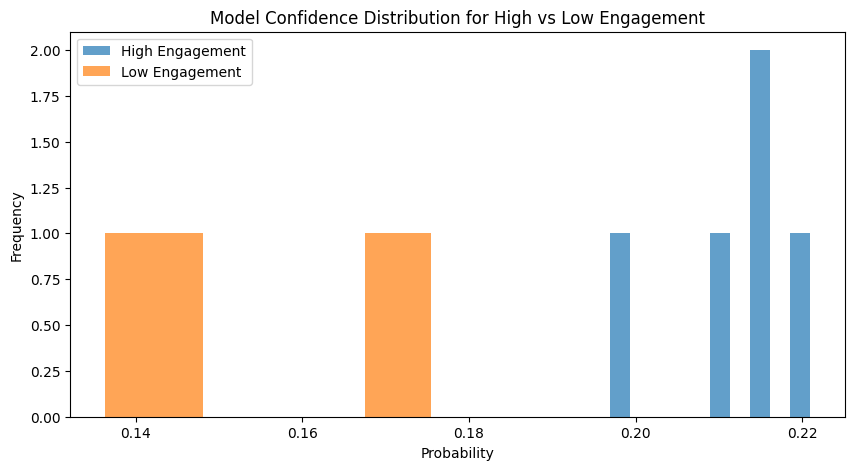

In [76]:
import matplotlib.pyplot as plt

# Function to visualize the confidence in predictions
def visualize_confidence(test_data, tokenizer, model):
    high_probabilities = []
    low_probabilities = []

    for text, expected_class in test_data:
        pred_class, prob = predict_with_bert(text, tokenizer, model)
        high_probabilities.append(prob[1])  # Probability of "High"
        low_probabilities.append(prob[0])  # Probability of "Low"

    # Plotting the histogram
    plt.figure(figsize=(10, 5))
    plt.hist(high_probabilities, bins=10, alpha=0.7, label="High Engagement")
    plt.hist(low_probabilities, bins=10, alpha=0.7, label="Low Engagement")
    plt.title("Model Confidence Distribution for High vs Low Engagement")
    plt.xlabel("Probability")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

# Visualize the model’s confidence
visualize_confidence(test_data, tokenizer, model)


<ipython-input-79-7d8310b97330>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Predicted', data=df, palette='cool')


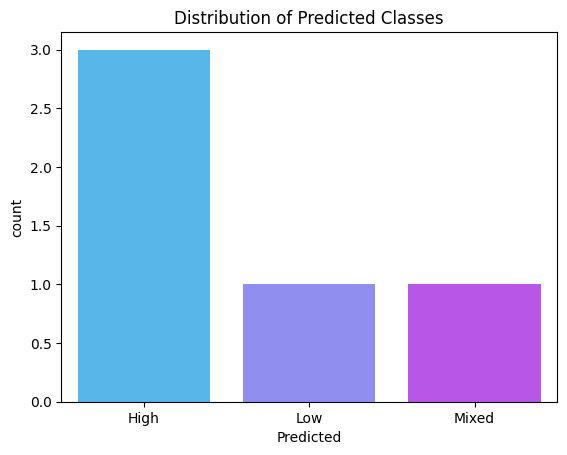

In [79]:
import seaborn as sns
import pandas as pd

df = pd.DataFrame(results, columns=['Text', 'Expected', 'Predicted', 'Prob', 'Sent', 'Conf', 'Sent_Label'])
sns.countplot(x='Predicted', data=df, palette='cool')
plt.title('Distribution of Predicted Classes')
plt.show()


Collected Metrics:
{'Random Forest': {'accuracy': 0.7467, 'precision': 0.7059, 'recall': 0.7273, 'f1': 0.7164}, 'Logistic Regression': {'accuracy': 0.7467, 'precision': 0.7059, 'recall': 0.7273, 'f1': 0.7164}, 'BERT': {'accuracy': 0.76, 'precision': 0.7027, 'recall': 0.7879, 'f1': 0.7429}}

Metrics DataFrame:
                     accuracy  precision  recall      f1
Random Forest          0.7467     0.7059  0.7273  0.7164
Logistic Regression    0.7467     0.7059  0.7273  0.7164
BERT                   0.7600     0.7027  0.7879  0.7429


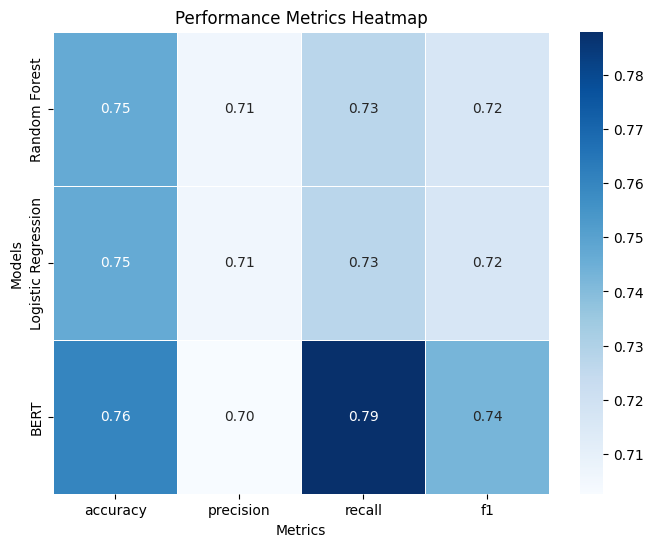

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Populated 'all_metrics' dictionary with the actual performance metrics
all_metrics = {
    "Random Forest": {"accuracy": 0.7467, "precision": 0.7059, "recall": 0.7273, "f1": 0.7164},
    "Logistic Regression": {"accuracy": 0.7467, "precision": 0.7059, "recall": 0.7273, "f1": 0.7164},
    "BERT": {"accuracy": 0.7600, "precision": 0.7027, "recall": 0.7879, "f1": 0.7429}
}

# Print the all_metrics dictionary to check the collected values
print("Collected Metrics:")
print(all_metrics)

# Convert the metrics to a DataFrame
metrics_df = pd.DataFrame(all_metrics).T

# Check the structure of the DataFrame
print("\nMetrics DataFrame:")
print(metrics_df)

# Create a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(metrics_df, annot=True, cmap="Blues", fmt=".2f", cbar=True, linewidths=0.5)

# Customize plot
plt.title('Performance Metrics Heatmap')
plt.xlabel('Metrics')
plt.ylabel('Models')

# Display the plot
plt.show()


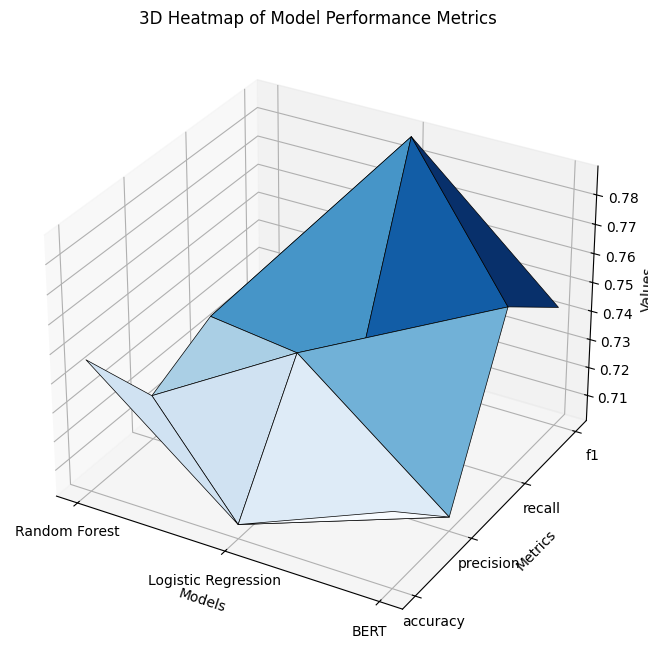

In [83]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd

# Populated 'all_metrics' dictionary with the actual performance metrics
all_metrics = {
    "Random Forest": {"accuracy": 0.7467, "precision": 0.7059, "recall": 0.7273, "f1": 0.7164},
    "Logistic Regression": {"accuracy": 0.7467, "precision": 0.7059, "recall": 0.7273, "f1": 0.7164},
    "BERT": {"accuracy": 0.7600, "precision": 0.7027, "recall": 0.7879, "f1": 0.7429}
}

# Convert the metrics to a DataFrame
metrics_df = pd.DataFrame(all_metrics).T

# Prepare 3D plot data
models = list(metrics_df.index)  # Model names (x-axis)
metrics = list(metrics_df.columns)  # Metric names (y-axis)
values = metrics_df.values  # Metric values (z-axis)

# Create meshgrid for plotting
x_pos, y_pos = np.meshgrid(range(len(models)), range(len(metrics)))

# Flatten the meshgrid arrays for the 3D plot
x_pos = x_pos.flatten()
y_pos = y_pos.flatten()
z_pos = values.flatten()

# Plotting the 3D heatmap (surface plot)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot a surface
ax.plot_trisurf(x_pos, y_pos, z_pos, cmap="Blues", linewidth=0.5, edgecolor="k")

# Set labels for the axes
ax.set_xlabel('Models')
ax.set_ylabel('Metrics')
ax.set_zlabel('Values')

# Set ticks to represent model names and metric names
ax.set_xticks(np.arange(len(models)))
ax.set_xticklabels(models)

ax.set_yticks(np.arange(len(metrics)))
ax.set_yticklabels(metrics)

# Title for the plot
ax.set_title('3D Heatmap of Model Performance Metrics')

# Show the plot
plt.show()
